# Load Models

In [1]:
from ultralytics import YOLO
import cv2

original_model_x = YOLO('yolo26x.pt')
original_model_s = YOLO('yolo26s.pt')
custom_model_x = YOLO('all_bottle_runs_v3/v1_specialized/weights/best.pt')
custom_model_s = YOLO('all_bottle_runs_v3/v2_specialized2/weights/best.pt')

# Quick Comparison


image 1/1 c:\TACO\test_images\test_img_1.jpg: 448x640 4 bottles, 61.2ms
Speed: 5.3ms preprocess, 61.2ms inference, 45.3ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 c:\TACO\test_images\test_img_1.jpg: 448x640 (no detections), 60.4ms
Speed: 1.6ms preprocess, 60.4ms inference, 0.3ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 c:\TACO\test_images\test_img_1.jpg: 448x640 7 bottles, 29.4ms
Speed: 1.6ms preprocess, 29.4ms inference, 0.5ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 c:\TACO\test_images\test_img_1.jpg: 448x640 4 bottles, 14.1ms
Speed: 1.2ms preprocess, 14.1ms inference, 0.4ms postprocess per image at shape (1, 3, 448, 640)


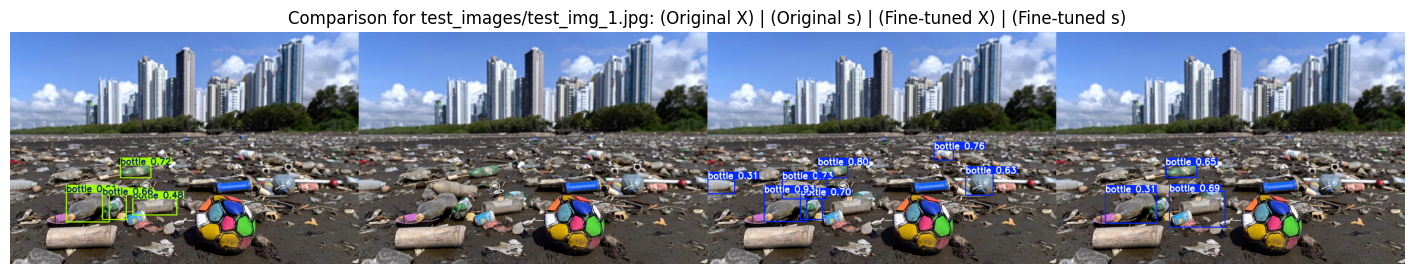


image 1/1 c:\TACO\test_images\test_img_2.jpg: 448x640 (no detections), 27.8ms
Speed: 1.2ms preprocess, 27.8ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 c:\TACO\test_images\test_img_2.jpg: 448x640 (no detections), 10.8ms
Speed: 1.4ms preprocess, 10.8ms inference, 0.4ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 c:\TACO\test_images\test_img_2.jpg: 448x640 (no detections), 26.7ms
Speed: 1.2ms preprocess, 26.7ms inference, 0.3ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 c:\TACO\test_images\test_img_2.jpg: 448x640 (no detections), 8.6ms
Speed: 1.2ms preprocess, 8.6ms inference, 0.3ms postprocess per image at shape (1, 3, 448, 640)


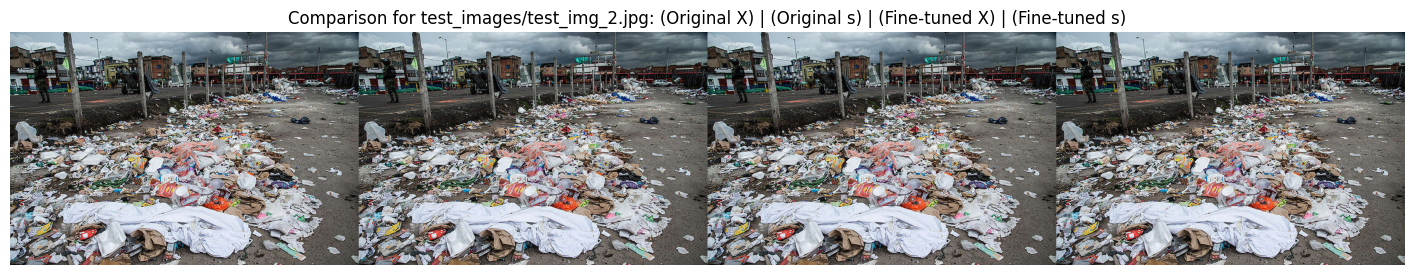


image 1/1 c:\TACO\test_images\test_img_3.jpg: 640x416 22 bottles, 59.8ms
Speed: 1.4ms preprocess, 59.8ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 416)

image 1/1 c:\TACO\test_images\test_img_3.jpg: 640x416 7 bottles, 59.2ms
Speed: 1.2ms preprocess, 59.2ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 416)

image 1/1 c:\TACO\test_images\test_img_3.jpg: 640x416 5 bottles, 26.3ms
Speed: 1.4ms preprocess, 26.3ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 416)

image 1/1 c:\TACO\test_images\test_img_3.jpg: 640x416 2 bottles, 19.4ms
Speed: 1.2ms preprocess, 19.4ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 416)


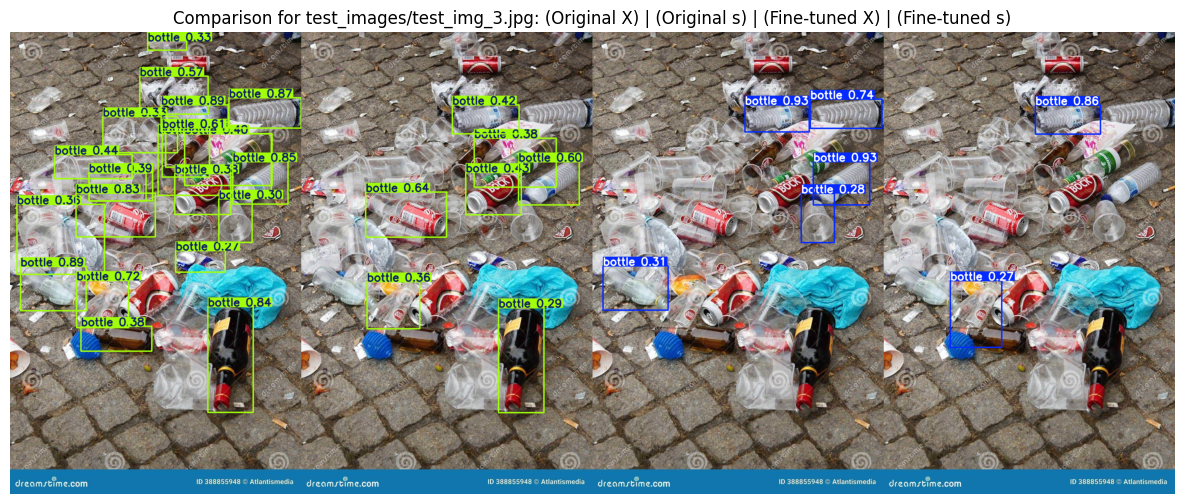


image 1/1 c:\TACO\test_images\test_img_4.jpg: 448x640 (no detections), 28.0ms
Speed: 1.6ms preprocess, 28.0ms inference, 0.7ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 c:\TACO\test_images\test_img_4.jpg: 448x640 (no detections), 9.3ms
Speed: 1.3ms preprocess, 9.3ms inference, 0.6ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 c:\TACO\test_images\test_img_4.jpg: 448x640 (no detections), 27.3ms
Speed: 1.5ms preprocess, 27.3ms inference, 0.3ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 c:\TACO\test_images\test_img_4.jpg: 448x640 (no detections), 8.7ms
Speed: 1.3ms preprocess, 8.7ms inference, 0.2ms postprocess per image at shape (1, 3, 448, 640)


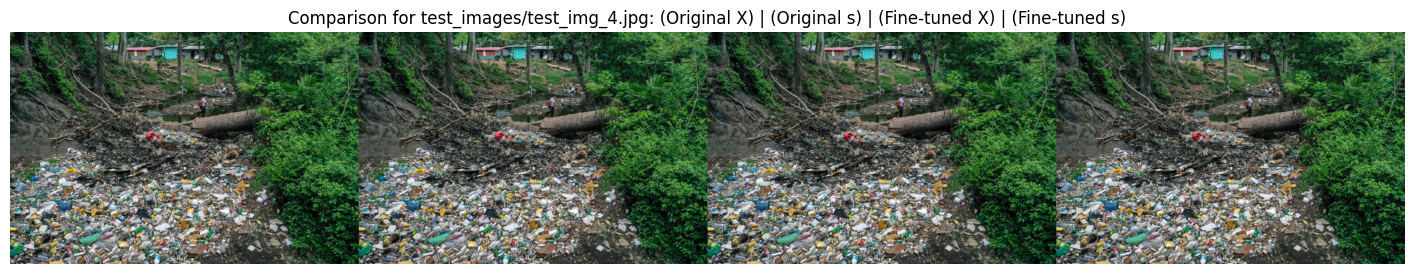


image 1/1 c:\TACO\test_images\test_img_5.jpg: 448x640 (no detections), 27.7ms
Speed: 1.3ms preprocess, 27.7ms inference, 1.2ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 c:\TACO\test_images\test_img_5.jpg: 448x640 (no detections), 11.7ms
Speed: 1.5ms preprocess, 11.7ms inference, 0.5ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 c:\TACO\test_images\test_img_5.jpg: 448x640 5 bottles, 26.9ms
Speed: 1.7ms preprocess, 26.9ms inference, 0.6ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 c:\TACO\test_images\test_img_5.jpg: 448x640 6 bottles, 8.5ms
Speed: 1.4ms preprocess, 8.5ms inference, 0.4ms postprocess per image at shape (1, 3, 448, 640)


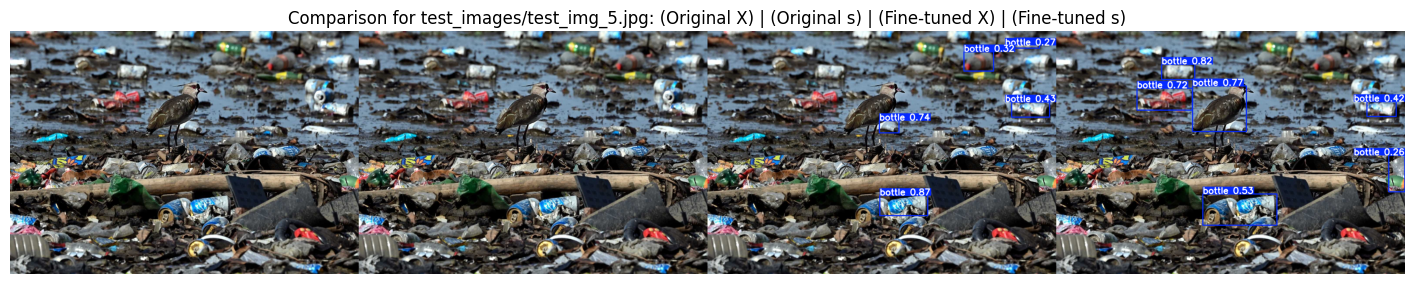

In [2]:
import numpy as np
import matplotlib.pyplot as plt

for image_number in range(1,6):
    image_path = f"test_images/test_img_{image_number}.jpg"
    res_original_x = original_model_x(image_path, classes=[39])
    res_original_s = original_model_s(image_path, classes=[39])
    res_custom_x = custom_model_x(image_path)
    res_custom_s = custom_model_s(image_path)

    imgs = []
    for r in (res_original_x, res_original_s, res_custom_x, res_custom_s):
        img = r[0].plot()
        if hasattr(img, "size"):
            img = np.array(img)
        imgs.append(img.astype("uint8"))

    heights = [im.shape[0] for im in imgs]
    target_h = min(heights)
    imgs_resized = [cv2.resize(im, (int(im.shape[1] * target_h / im.shape[0]), target_h))
                    if im.shape[0] != target_h else im for im in imgs]

    combined = cv2.hconcat(imgs_resized)

    try:
        combined_rgb = cv2.cvtColor(combined, cv2.COLOR_BGR2RGB)
    except Exception:
        combined_rgb = combined

    plt.figure(figsize=(18, 6))
    plt.imshow(combined_rgb)
    plt.axis("off")
    plt.title(f"Comparison for {image_path}: (Original X) | (Original s) | (Fine-tuned X) | (Fine-tuned s)")
    plt.show()

# Numerical Comparison

In [3]:
data_yaml_path = 'yolo_bottle_dataset/data.yaml'

metrics_original_x = original_model_x.val(data=data_yaml_path)
metrics_original_s = original_model_s.val(data=data_yaml_path)
metrics_custom_x = custom_model_x.val(data=data_yaml_path)
metrics_custom_s = custom_model_s.val(data=data_yaml_path)

Ultralytics 8.4.32  Python-3.10.11 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
val: Fast image access  (ping: 0.20.1 ms, read: 1001.0317.5 MB/s, size: 1115.1 KB)
val: Scanning C:\TACO\yolo_bottle_dataset\labels\val.cache... 74 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 74/74  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.4s/it 6.9s1.1sss
                   all         74         89     0.0267     0.0787     0.0145     0.0129
                person         74         89     0.0267     0.0787     0.0145     0.0129
Speed: 6.2ms preprocess, 39.1ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to C:\TACO\runs\detect\val7
Ultralytics 8.4.32  Python-3.10.11 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
val: Fast image access  (ping: 0.00.0 ms, read: 2520.3270.0 MB/s, size: 1951.4 KB)
val: Scanning C:\TACO\yolo_bottle_dataset\labels\val.cach

In [10]:
import pandas as pd

# Build summary DataFrame for all tested models
models = {
    'original_x': metrics_original_x,
    'original_s': metrics_original_s,
    'custom_x': metrics_custom_x,
    'custom_s': metrics_custom_s,
}

summaries = {}
for name, m in models.items():
    try:
        s = m.summary()
    except Exception as e:
        s = f'error: {e}'
    if isinstance(s, (list, tuple)) and s and isinstance(s[0], dict):
        summaries[name] = s[0]
    elif isinstance(s, dict):
        summaries[name] = s
    else:
        summaries[name] = {'raw_summary': s}

df_summaries = pd.DataFrame.from_dict(summaries, orient='index')
df_summaries


,Class,Images,Instances,Box-P,Box-R,Box-F1,mAP50,mAP50-95
original_x,person,74,89,0.02672,0.07865,0.03989,0.01446,0.01292
original_s,person,74,89,0.02576,0.12360,0.04264,0.01523,0.01405
custom_x,bottle,74,89,0.80208,0.73034,0.76453,0.80224,0.65597
custom_s,bottle,74,89,0.83067,0.71658,0.76942,0.76830,0.66246


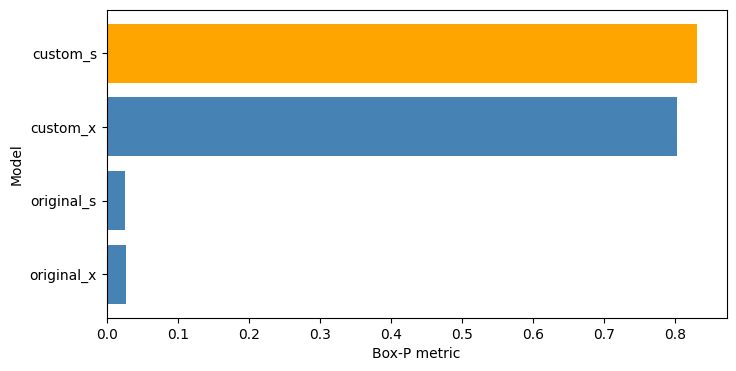

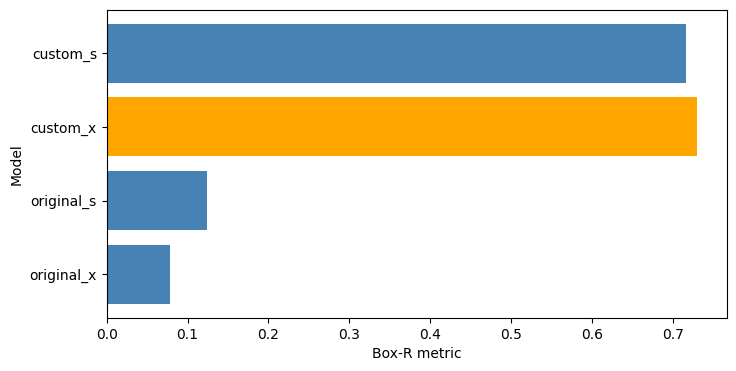

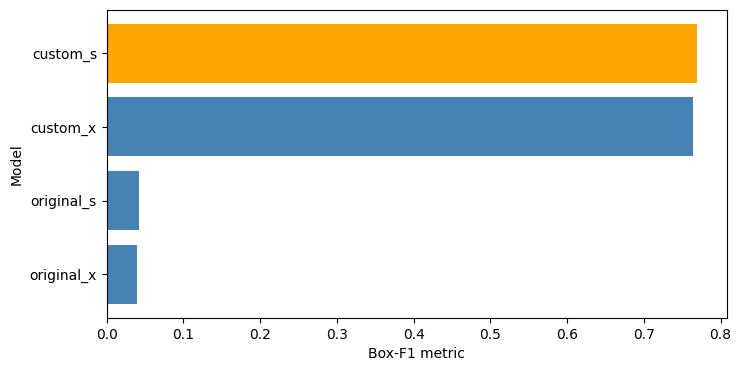

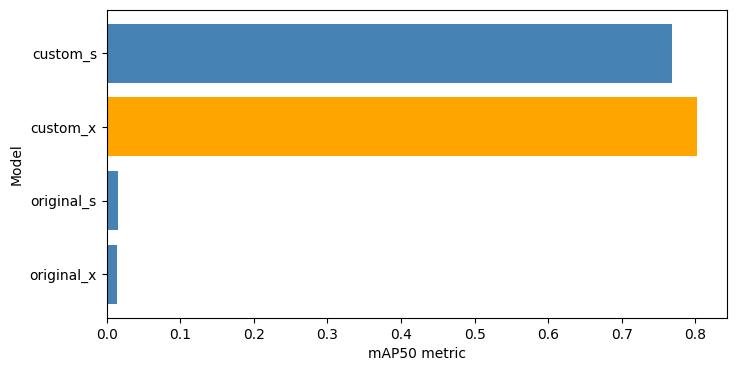

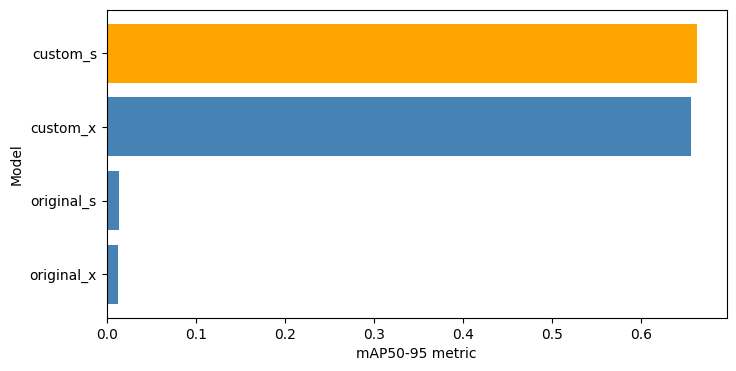

In [29]:
df_floats = df_summaries.select_dtypes(include=['float64'])

for metric in df_floats.columns:
    vals = df_summaries[metric].fillna(0)
    colors = ['orange' if v == vals.max() else 'steelblue' for v in vals]
    plt.figure(figsize=(8,4))
    plt.barh(vals.index, vals, color=colors)
    plt.xlabel(f"{metric} metric")
    plt.ylabel('Model')
    plt.show()